In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import os
import sys
from sklearn.preprocessing import MaxAbsScaler
# append source to sys path
src_path = '../src' 
if src_path not in sys.path:
    sys.path.append(src_path)

import dataprocessing as dp

## Read data

In [3]:
data_A = dp.read_data('A')
data_B = dp.read_data('B')
data_C = dp.read_data('C')

data_A.head()

,absolute_humidity_2m:gm3,air_density_2m:kgm3,ceiling_height_agl:m,clear_sky_energy_1h:J,clear_sky_rad:W,cloud_base_agl:m,dew_or_rime:idx,dew_point_2m:K,diffuse_rad:W,diffuse_rad_1h:J,...,sun_elevation:d,super_cooled_liquid_water:kgm2,t_1000hPa:K,total_cloud_cover:p,visibility:m,wind_speed_10m:ms,wind_speed_u_10m:ms,wind_speed_v_10m:ms,wind_speed_w_1000hPa:ms,pv_measurement
2019-06-02 22:00:00,7.7,1.230,1744.900024,0.0,0.0,1744.900024,0.0,280.299988,0.0,0.0,...,-3.202,0.0,285.899994,100.0,39640.101562,3.7,-3.6,-0.8,-0.0,0.0
2019-06-02 22:15:00,7.7,1.229,1734.000000,0.0,0.0,1734.000000,0.0,280.299988,0.0,0.0,...,-3.650,0.0,286.100006,100.0,40123.898438,3.6,-3.6,-0.6,-0.0,NaN
2019-06-02 22:30:00,7.7,1.228,1723.500000,0.0,0.0,1723.500000,0.0,280.299988,0.0,0.0,...,-3.998,0.0,286.299988,100.0,40628.300781,3.6,-3.6,-0.4,-0.0,NaN
2019-06-02 22:45:00,7.7,1.226,1713.400024,0.0,0.0,1713.400024,0.0,280.299988,0.0,0.0,...,-4.247,0.0,286.600006,100.0,41153.601562,3.5,-3.5,-0.2,-0.0,NaN
2019-06-02 23:00:00,7.7,1.225,1703.599976,0.0,0.0,1703.599976,0.0,280.299988,0.0,0.0,...,-4.393,0.0,286.799988,100.0,41699.898438,3.5,-3.5,0.0,-0.0,0.0


In [4]:
def get_correlation_matrix(data: pd.DataFrame, method: str = 'kendall') -> pd.DataFrame:
    """
    Calculate the correlation matrix of the given DataFrame using the specified method.

    Parameters:
    data (pd.DataFrame): The input DataFrame.
    method (str): The correlation method to use ('pearson', 'kendall', 'spearman').

    Returns:
    pd.DataFrame: The correlation matrix.
    """
    correlation_matrix = data.corr(method=method)
    correlation_matrix.dropna(thresh=2, inplace=True)
    correlation_matrix.dropna(axis=1, thresh=2, inplace=True)
    return correlation_matrix

data_corr_A = get_correlation_matrix(data_A, method='kendall')
# data_corr_B = get_correlation_matrix(data_B, method='kendall')
# data_corr_C = get_correlation_matrix(data_C, method='kendall')

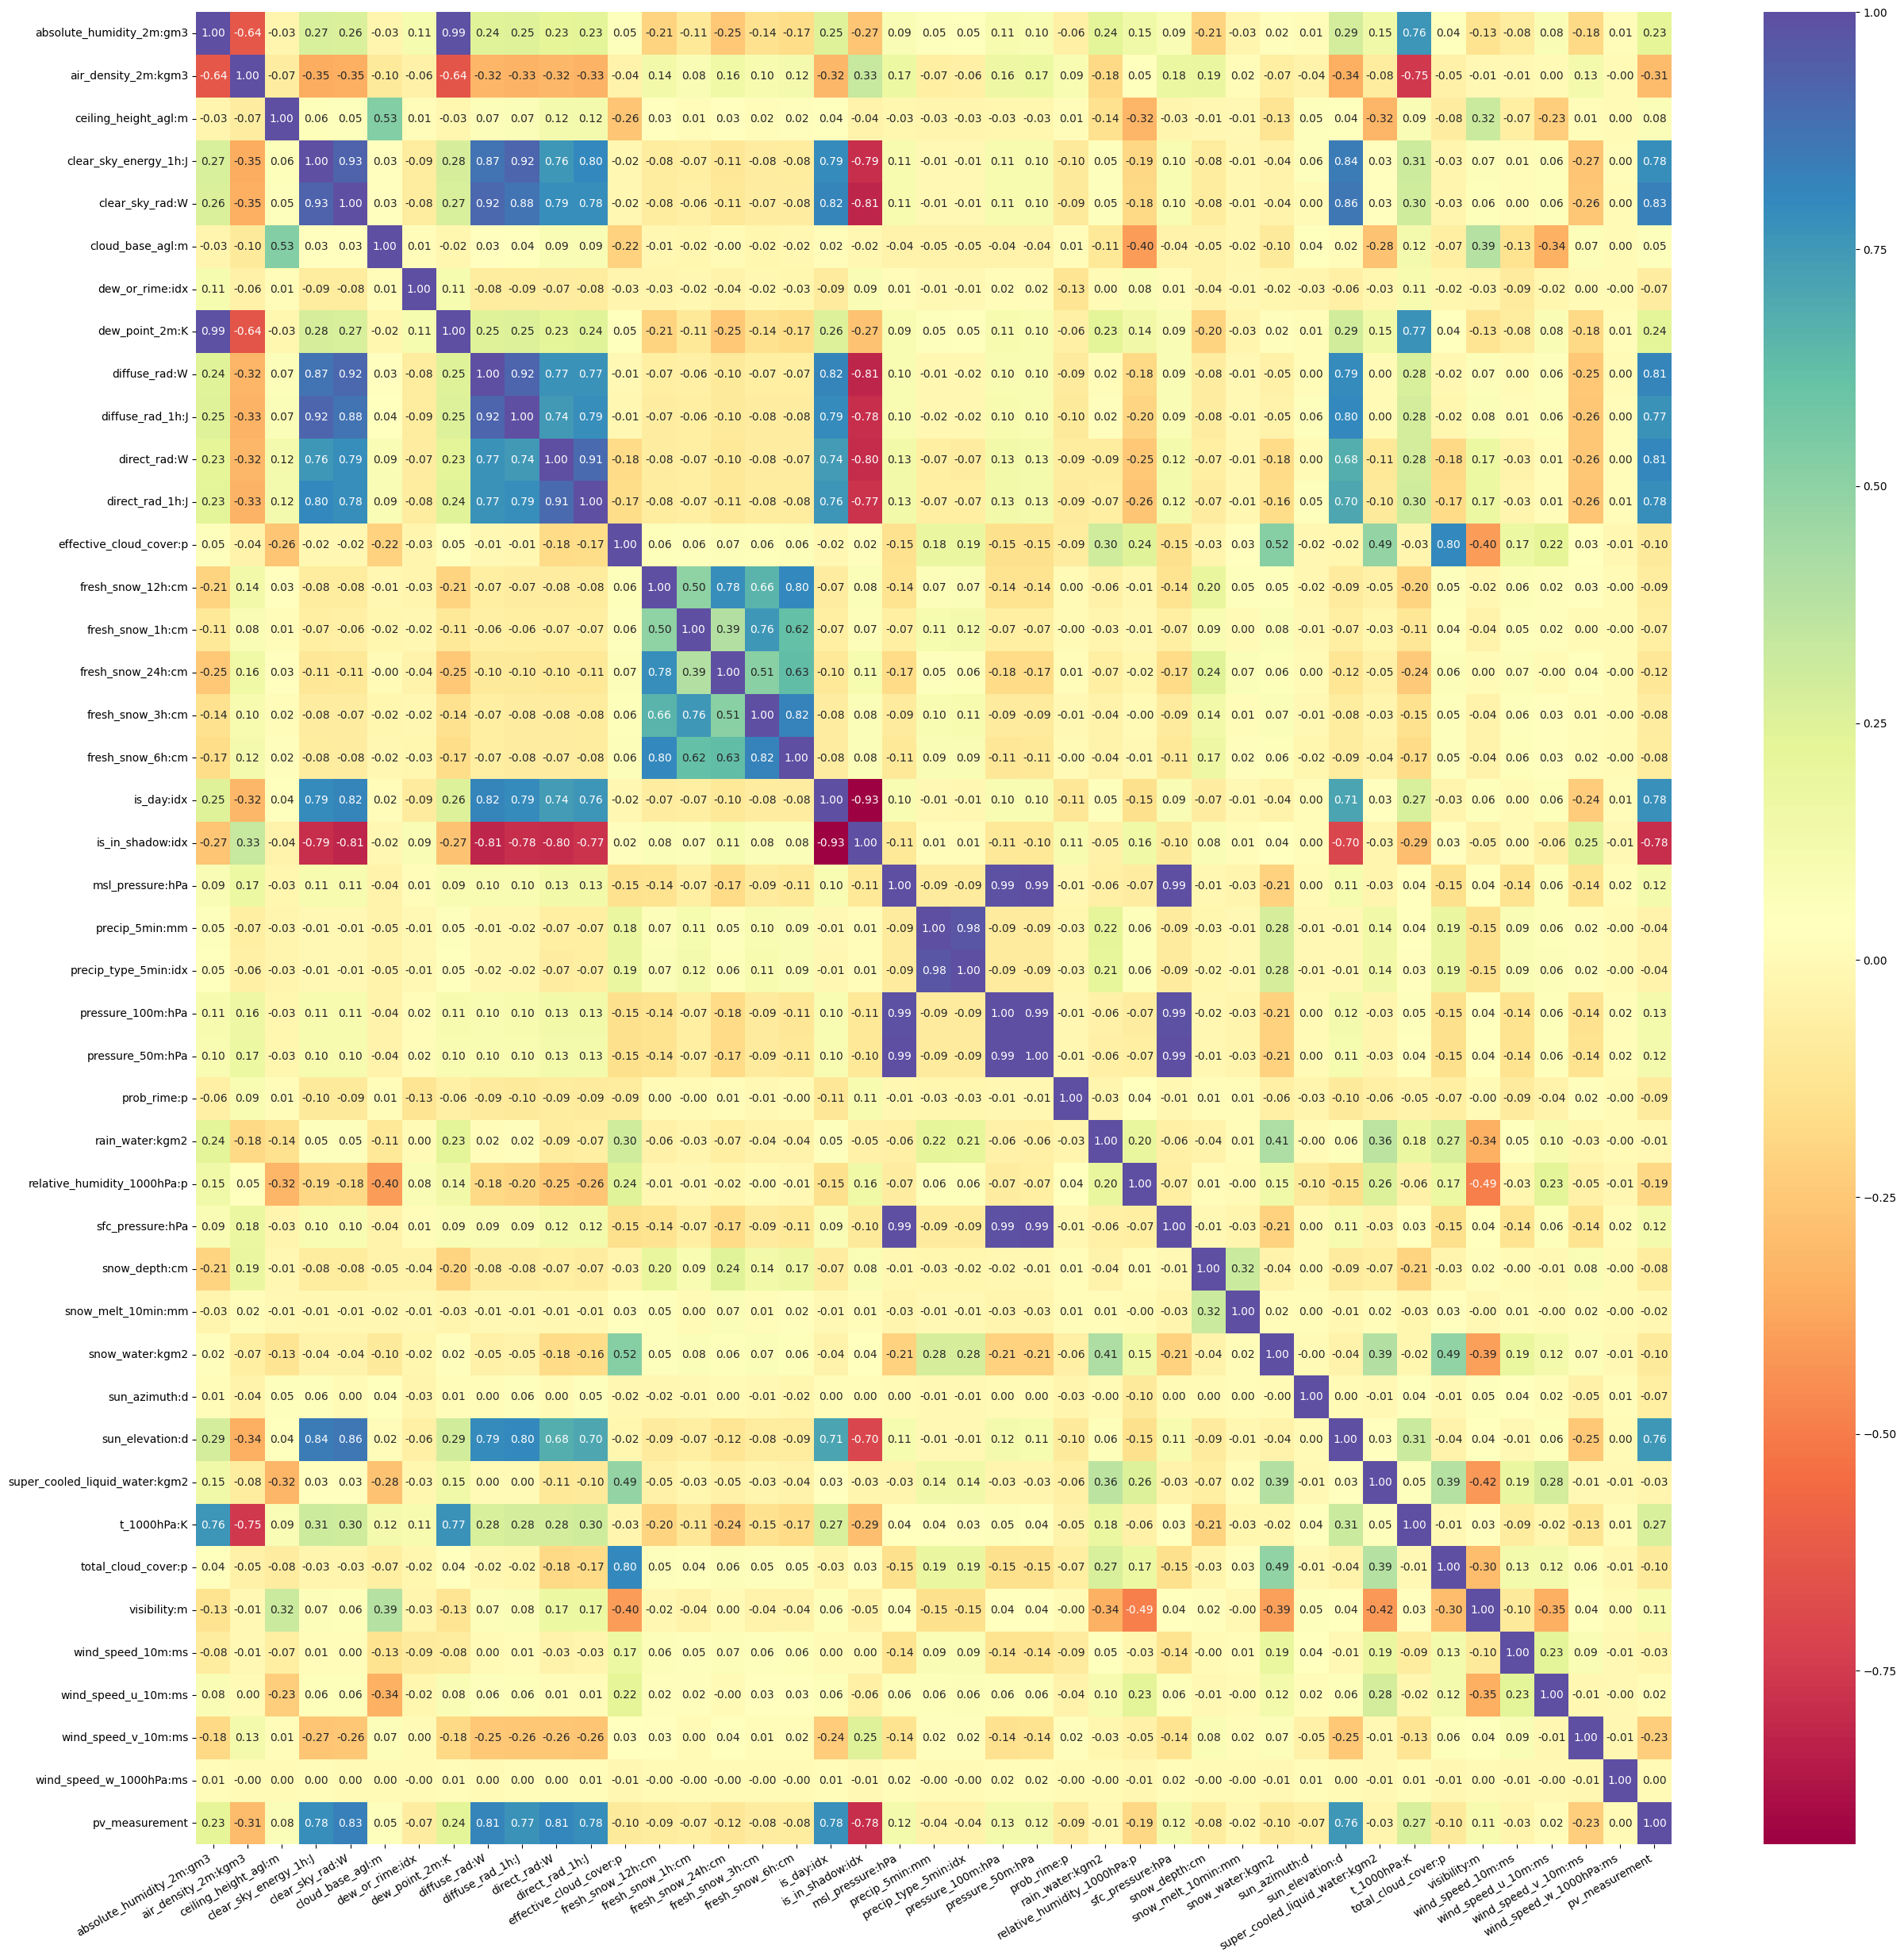


Redundant feature removal (Pearson correlation >= 0.93):
  Original features: 46
  Redundant pairs found: 12
  Redundant pairs: [('clear_sky_rad:W', 'clear_sky_energy_1h:J'), ('dew_point_2m:K', 'absolute_humidity_2m:gm3'), ('diffuse_rad_1h:J', 'diffuse_rad:W'), ('direct_rad_1h:J', 'direct_rad:W'), ('is_in_shadow:idx', 'is_day:idx'), ('pressure_100m:hPa', 'msl_pressure:hPa'), ('pressure_50m:hPa', 'msl_pressure:hPa'), ('pressure_50m:hPa', 'pressure_100m:hPa'), ('sfc_pressure:hPa', 'msl_pressure:hPa'), ('sfc_pressure:hPa', 'pressure_100m:hPa'), ('sfc_pressure:hPa', 'pressure_50m:hPa'), ('total_cloud_cover:p', 'effective_cloud_cover:p')]
  Features to drop: ['absolute_humidity_2m:gm3', 'clear_sky_energy_1h:J', 'diffuse_rad_1h:J', 'direct_rad_1h:J', 'is_day:idx', 'msl_pressure:hPa', 'pressure_50m:hPa', 'sfc_pressure:hPa', 'total_cloud_cover:p']
  Features remaining: 37


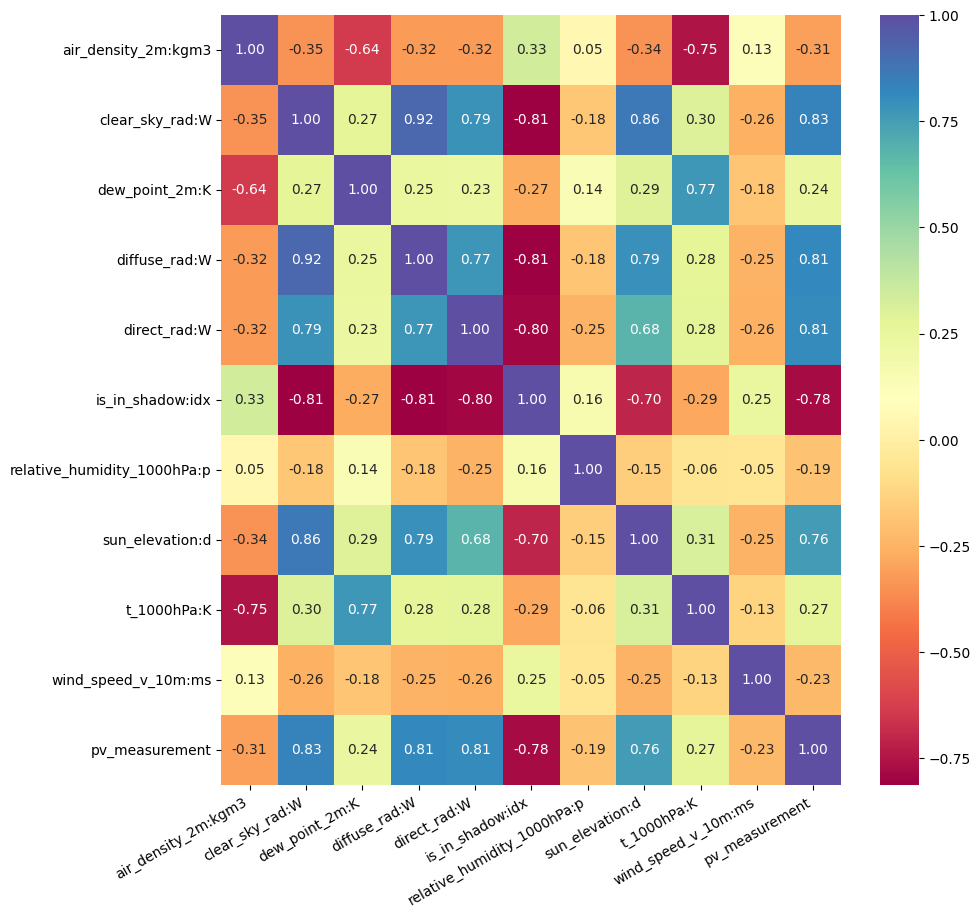

,air_density_2m:kgm3,clear_sky_rad:W,dew_point_2m:K,diffuse_rad:W,direct_rad:W,is_in_shadow:idx,relative_humidity_1000hPa:p,sun_elevation:d,t_1000hPa:K,wind_speed_v_10m:ms,pv_measurement
air_density_2m:kgm3,1.000000,-0.345165,-0.640364,-0.322922,-0.320510,0.334204,0.046086,-0.344521,-0.752138,0.125078,-0.305804
clear_sky_rad:W,-0.345165,1.000000,0.272359,0.916293,0.785692,-0.813582,-0.180129,0.863024,0.298669,-0.256845,0.830388
dew_point_2m:K,-0.640364,0.272359,1.000000,0.247837,0.234416,-0.274367,0.143284,0.294608,0.769735,-0.184207,0.235273
diffuse_rad:W,-0.322922,0.916293,0.247837,1.000000,0.773335,-0.812722,-0.184173,0.792612,0.275022,-0.248115,0.812388
direct_rad:W,-0.320510,0.785692,0.234416,0.773335,1.000000,-0.796165,-0.251871,0.679889,0.283956,-0.255216,0.805122
is_in_shadow:idx,0.334204,-0.813582,-0.274367,-0.812722,-0.796165,1.000000,0.159130,-0.704151,-0.288142,0.248661,-0.782270
relative_humidity_1000hPa:p,0.046086,-0.180129,0.143284,-0.184173,-0.251871,0.159130,1.000000,-0.147863,-0.057025,-0.050452,-0.192980
sun_elevation:d,-0.344521,0.863024,0.294608,0.792612,0.679889,-0.704151,-0.147863,1.000000,0.314307,-0.251422,0.756143
t_1000hPa:K,-0.752138,0.298669,0.769735,0.275022,0.283956,-0.288142,-0.057025,0.314307,1.000000,-0.131555,0.268225
wind_speed_v_10m:ms,0.125078,-0.256845,-0.184207,-0.248115,-0.255216,0.248661,-0.050452,-0.251422,-0.131555,1.000000,-0.230274


In [5]:
plt.figure(figsize=(30, 30))
sns.heatmap(data_corr_A, annot=True, fmt=".2f", cmap="Spectral")
plt.xticks(rotation=30, ha='right')
plt.show() #supress text output from seaborn


# keys = data_corr_A.drop(columns=["pv_measurement"]).keys()

most_corr_A = dp.filter_correlation_matrix(data_corr_A, threshold=0.15)
redundant_features = dp.remove_redundant_features(data_A, threshold=0.93, target_feature='pv_measurement', return_list=True)
redundant_features = set(redundant_features).intersection(set(most_corr_A.keys())) # only drop features present in most_corr_A

most_corr_A.drop(columns=redundant_features, index=redundant_features, inplace=True)

plt.figure(figsize=(10, 10))
sns.heatmap(most_corr_A, annot=True, fmt=".2f", cmap="Spectral")
plt.xticks(rotation=30, ha='right')
plt.show() #supress text output from seaborn


most_corr_A


### notes to self
* Kendall Tau is best for this kind of data, however, find redundancy with pearson >.95

## plot general overview (resampled daily mean og big subset)

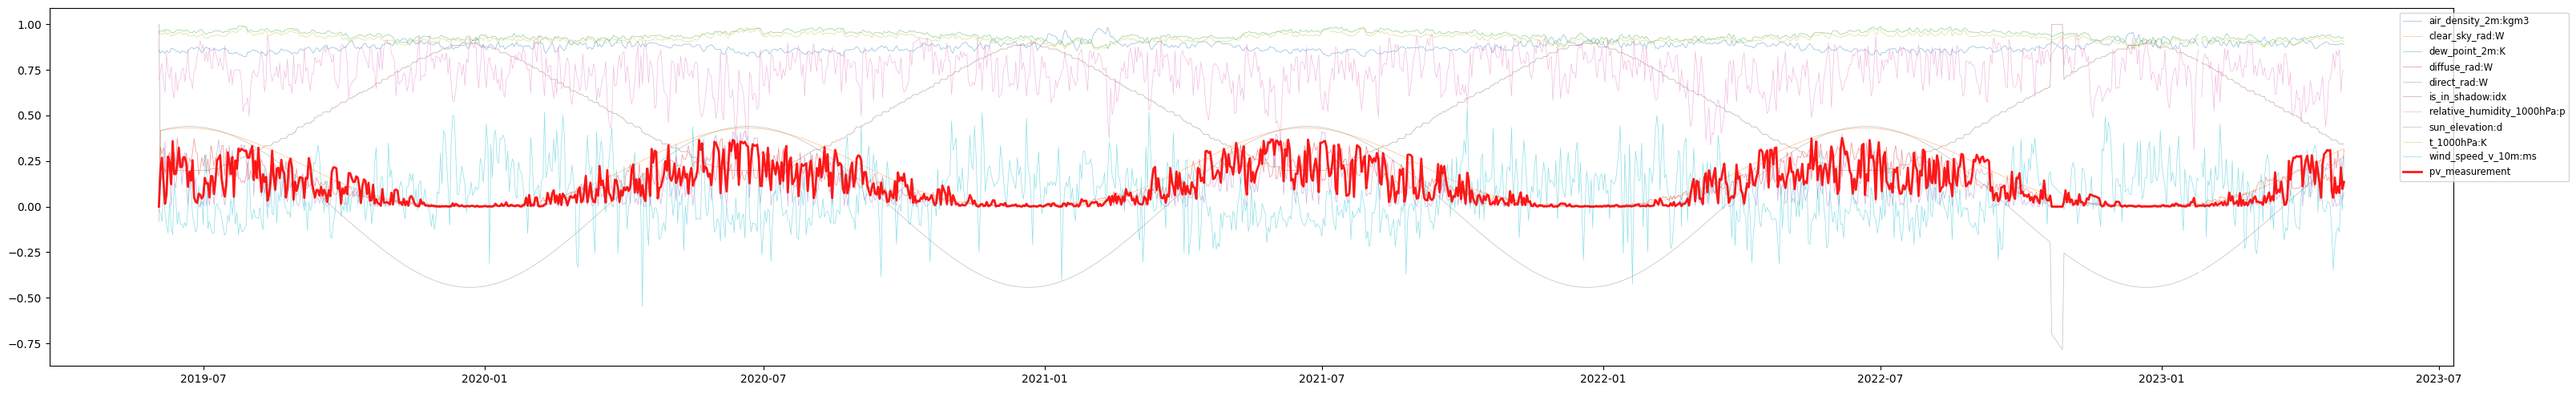

In [ ]:
scaler = MaxAbsScaler()
data_A_scaled = pd.DataFrame(scaler.fit_transform(data_A), columns=data_A.columns, index=data_A.index)
data_A_corr_scaled_pruned = data_A_corr_scaled[most_corr_A.columns].resample('D').mean()
data_A_corr_scaled.dropna(subset=['pv_measurement'], inplace=True)

plt.figure(figsize=(32, 5))

for col in data_A_corr_scaled.columns:
    if col != 'pv_measurement':
        plt.plot(data_A_corr_scaled.index, data_A_corr_scaled[col], alpha=0.5, linewidth=0.5, label=col)
plt.plot( data_A_corr_scaled.index, data_A_corr_scaled['pv_measurement'], color='red', alpha=0.9, linewidth=2, label='pv_measurement')
plt.legend(bbox_to_anchor=(1.05, 1), fontsize='small')
plt.tight_layout()
plt.show()


## Plot general overview of small subset (pv, direct_rad, diffuse rad and clear_sky_rad)

Index(['air_density_2m:kgm3', 'clear_sky_rad:W', 'dew_point_2m:K',
       'diffuse_rad:W', 'direct_rad:W', 'is_in_shadow:idx',
       'relative_humidity_1000hPa:p', 'sun_elevation:d', 't_1000hPa:K',
       'wind_speed_v_10m:ms', 'pv_measurement', 'hour', 'hour_sin', 'hour_cos',
       'day_of_year', 'day_sin', 'day_cos'],
      dtype='object')


/tmp/ipykernel_7950/2262760613.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_A_corr_scaled_pruned['hour'] = data_A_corr_scaled_pruned.index.hour/24
/tmp/ipykernel_7950/2262760613.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_A_corr_scaled_pruned['hour_sin'] = np.sin(2 * np.pi * data_A_corr_scaled_pruned['hour'] / 24)
/tmp/ipykernel_7950/2262760613.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

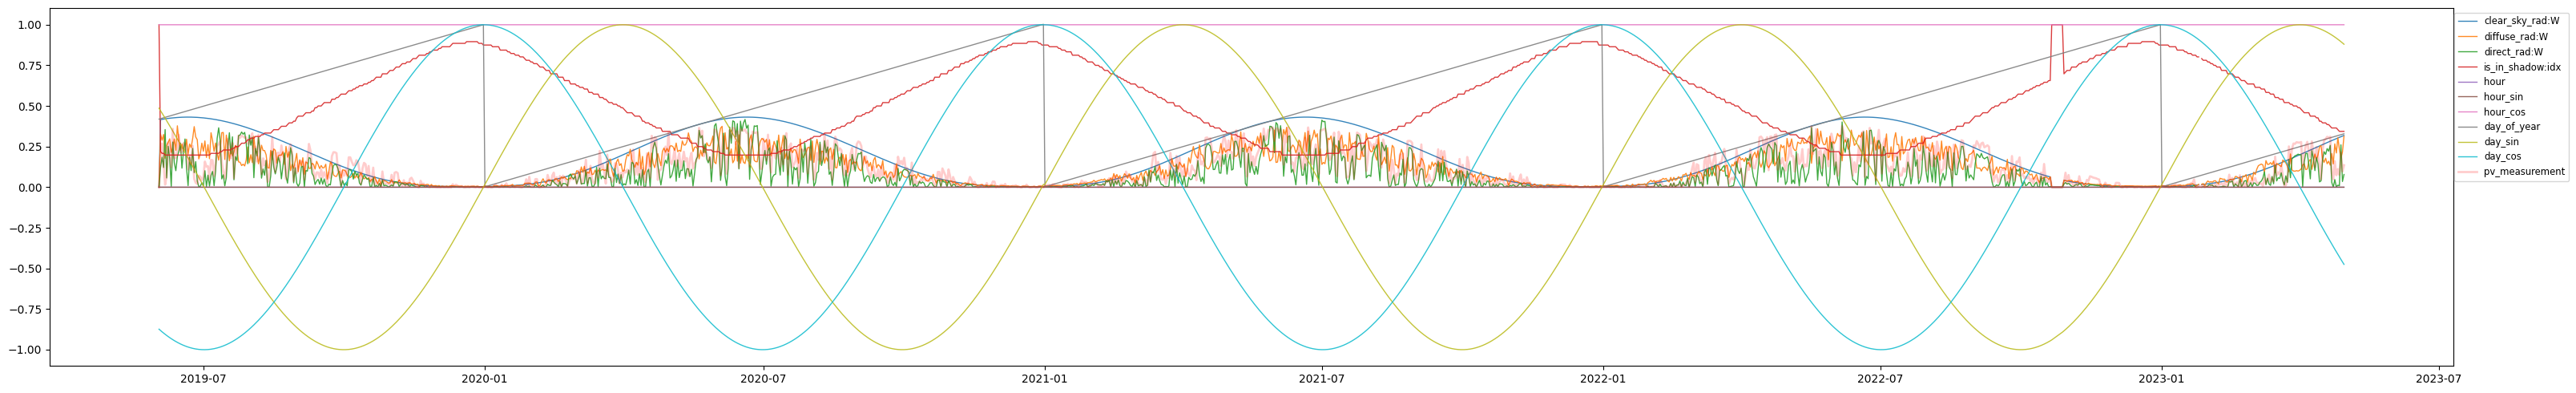

In [39]:
print(data_A_corr_scaled.columns)

data_A_corr_scaled_pruned = data_A_corr_scaled[['clear_sky_rad:W', 'diffuse_rad:W', 'direct_rad:W', 'pv_measurement', 'is_in_shadow:idx']]

#make cyclical time features
data_A_corr_scaled_pruned['hour'] = data_A_corr_scaled_pruned.index.hour/24
data_A_corr_scaled_pruned['hour_sin'] = np.sin(2 * np.pi * data_A_corr_scaled_pruned['hour'] / 24)
data_A_corr_scaled_pruned['hour_cos'] = np.cos(2 * np.pi * data_A_corr_scaled_pruned['hour'] / 24)

# Add cyclical features for day of the year
data_A_corr_scaled_pruned['day_of_year'] = data_A_corr_scaled_pruned.index.dayofyear/365
data_A_corr_scaled_pruned['day_sin'] = np.sin(2 * np.pi * data_A_corr_scaled_pruned['day_of_year'] )
data_A_corr_scaled_pruned['day_cos'] = np.cos(2 * np.pi * data_A_corr_scaled_pruned['day_of_year'] )


plt.figure(figsize=(32, 5))
for col in data_A_corr_scaled_pruned.columns:
    if col != 'pv_measurement':
        plt.plot(data_A_corr_scaled_pruned.index, data_A_corr_scaled_pruned[col], alpha=0.9, linewidth=1, label=col)
plt.plot( data_A_corr_scaled_pruned.index, data_A_corr_scaled_pruned['pv_measurement'], color='red', alpha=0.2, linewidth=2, label='pv_measurement')
plt.legend(bbox_to_anchor=(1.05, 1), fontsize='small')
plt.tight_layout()
plt.show()



### Plot a single month of small subset without resampling

In [38]:
data_A_scaled_day = data_A[data_A_corr_scaled_pruned.columns].loc['2020-03-01':'2020-06-01']
data_A_scaled_day = pd.DataFrame(scaler.fit_transform(data_A_scaled_day), columns=data_A_scaled_day.columns, index=data_A_scaled_day.index)
data_A_scaled_day.dropna(subset=['pv_measurement'], inplace=True)

plt.figure(figsize=(32, 5))
for col in data_A_scaled_day.columns:
    if col != 'pv_measurement':
        plt.plot(data_A_scaled_day.index, data_A_scaled_day[col], alpha=0.9, linewidth=1, label=col)
plt.plot( data_A_scaled_day.index, data_A_scaled_day['pv_measurement'], color='red', alpha=0.2, linewidth=2, label='pv_measurement')
plt.legend(bbox_to_anchor=(1.05, 1), fontsize='small')
plt.tight_layout()
plt.show()

KeyError: "['hour', 'hour_sin', 'hour_cos', 'day_of_year', 'day_sin', 'day_cos'] not in index"

In [ ]:
# Group data by day and calculate the correlation between 'direct_rad:W' and 'pv_measurement'
daily_correlations = data_A_scaled_day.groupby(data_A_scaled_day.index.date).apply(
    lambda group: group[['direct_rad:W', 'pv_measurement']].corr(method='kendall').iloc[0, 1]
)

# Find the day with the highest correlation
most_correlated_day = daily_correlations.idxmax()
most_correlation_value = daily_correlations.max()

# Find the day with the lowest correlation
least_correlated_day = daily_correlations.idxmin()
least_correlation_value = daily_correlations.min()

# Print the results
print(f"Day with highest correlation: {most_correlated_day}, Correlation: {most_correlation_value:.2f}")
print(f"Day with lowest correlation: {least_correlated_day}, Correlation: {least_correlation_value:.2f}")

Day with highest correlation: 2020-04-20, Correlation: 0.93
Day with lowest correlation: 2020-04-15, Correlation: 0.51


Notes to self: Burde sikkert ha en feature som fanger seasonality (ref. clear sky radiation funker som et tak for pv om sommeren, men ikke våren/høsten)

Kan det funke å bruke en typ svm regressor på dato (uten år) mot pv som en feature? (For tilfeller radiation bommer)


Ikke glem å ta en ny kikk på idx-features. Her har de bare blitt fjernet fordi de ikke får correlation til pv

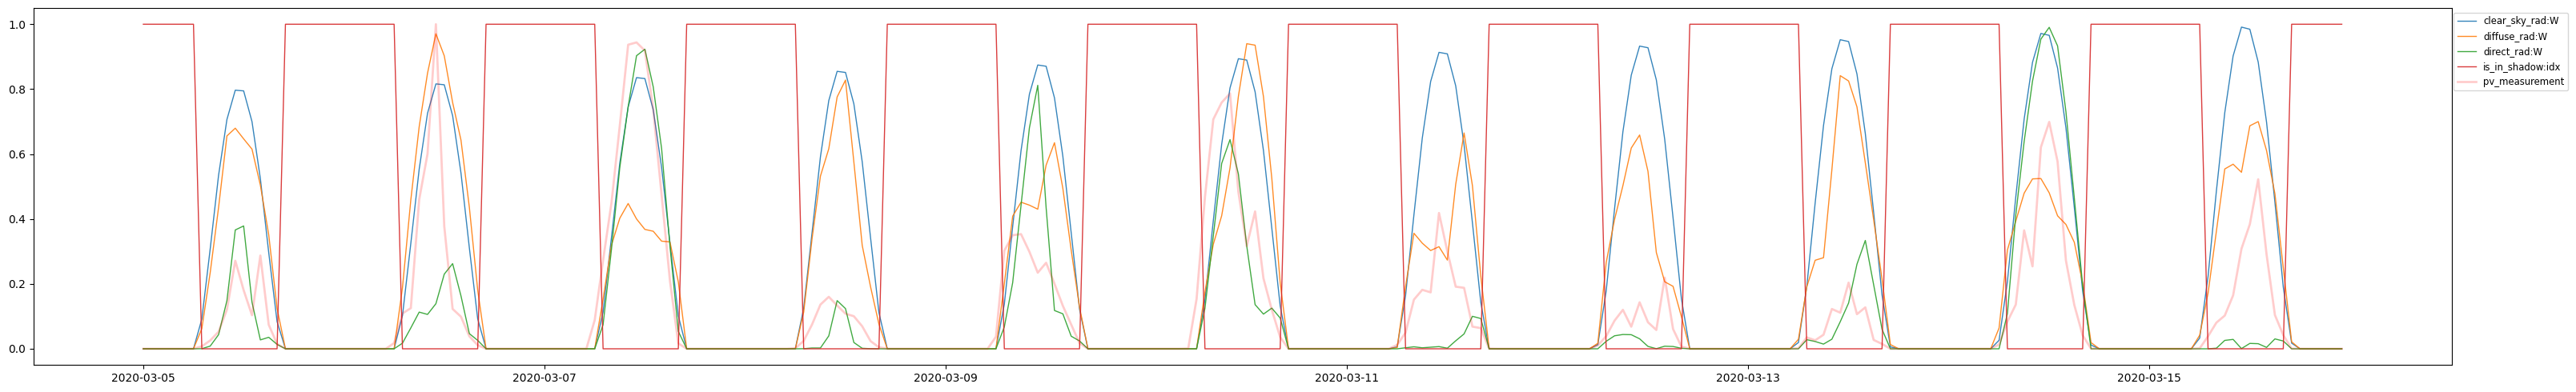

In [ ]:
data_A_scaled_day = data_A[data_A_corr_scaled_pruned.columns].loc['2020-03-5':'2020-03-15']
data_A_scaled_day = pd.DataFrame(scaler.fit_transform(data_A_scaled_day), columns=data_A_scaled_day.columns, index=data_A_scaled_day.index)
data_A_scaled_day.dropna(subset=['pv_measurement'], inplace=True)

plt.figure(figsize=(32, 5))
for col in data_A_scaled_day.columns:
    if col != 'pv_measurement':
        plt.plot(data_A_scaled_day.index, data_A_scaled_day[col], alpha=0.9, linewidth=1, label=col)
plt.plot( data_A_scaled_day.index, data_A_scaled_day['pv_measurement'], color='red', alpha=0.2, linewidth=2, label='pv_measurement')
plt.legend(bbox_to_anchor=(1.05, 1), fontsize='small')
plt.tight_layout()
plt.show()